In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
import pickle
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve
)

from sklearn.impute import SimpleImputer
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.svm             import SVC
from sklearn.ensemble import IsolationForest
from sklearn.base import BaseEstimator, ClassifierMixin
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

from imblearn.over_sampling  import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler

In [2]:
dt = pd.read_csv('/kaggle/input/datasets/furkanbaykal/train-dtt/train_cleaned.csv')

In [3]:
# Explicitly define X, y, X_train, X_test, y_train, y_test here to fix the NameError
X = dt.drop(columns=['isFraud'])
y = dt['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
def apply_final_target_encoding(X_train, X_test, y_train):
    """
    Applies Target Encoding AFTER the train/test split.
    Includes both V columns and cleaned Group 3 IT features.
    """
    print("Log: Starting Final Target Encoding phase (Post-Split)...")
    
    # Updated list: Removed 'P_emaildomain' and raw 'id_31'. 
    # Added cleaned base features and 'id_33'.
    target_encode_cols = [
        # Cleaned IT Features (Group 3)
        'id_30_base', 'id_31_base', 'device_brand', 'id_33',
        
        # V Columns
        'V2', 'V4', 'V5', 'V8', 'V9', 'V11', 'V13', 'V15', 'V19', 'V21', 
        'V22', 'V25', 'V29', 'V30', 'V31', 'V33', 'V36', 'V42', 'V43', 'V46', 
        'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V57', 'V61', 
        'V63', 'V64', 'V66', 'V67', 'V69', 'V70', 'V71', 'V73', 'V74', 'V76', 
        'V79', 'V82', 'V83', 'V84', 'V85', 'V90', 'V91', 'V92', 'V93', 'V108', 
        'V109', 'V110', 'V114', 'V115', 'V116', 'V173', 'V174', 'V194', 'V240', 
        'V241', 'V260', 'V286'
    ]
    
    # Ensure columns actually exist in the current dataframe
    valid_cols = [col for col in target_encode_cols if col in X_train.columns]
    print(f"Log: Fitting TargetEncoder on {len(valid_cols)} columns using training data only...")
    
    # Initialize encoder with smoothing
    encoder = TargetEncoder(cols=valid_cols, smoothing=10.0)
    
    # 1. FIT & TRANSFORM on Training Data
    train_encoded = encoder.fit_transform(X_train, y_train)
    
    # 2. TRANSFORM ONLY on Test Data
    print("Log: Transforming test data based on training mappings...")
    test_encoded = encoder.transform(X_test)
    
    print("Log: Target Encoding completed without data leakage.")
    return train_encoded, test_encoded

In [5]:
X_train, X_test = apply_final_target_encoding(X_train, X_test, y_train)

Log: Starting Final Target Encoding phase (Post-Split)...
Log: Fitting TargetEncoder on 63 columns using training data only...
Log: Transforming test data based on training mappings...
Log: Target Encoding completed without data leakage.


In [6]:
scaler = StandardScaler()

# 1. Identify all categorical (object) columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# 2. Apply One-Hot Encoding
X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)

# ---> Align the columns of both dataframes <---
# Ensures X_test has the exact same columns as X_train
# Missing columns in test are filled with 0, extra unseen categories are dropped
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 3. Convert boolean columns to 0/1 (float) for safer scaling
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit() ONLY on train
X_test_scaled  = scaler.transform(X_test)        # transform() applied to both

# index=X_train.index satırı eklenmezse SMOTE sentetik veri üretirken satırları karıştırır!
X_train_s = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_s  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print('Scaling complete.')
print(f'Train mean ≈ 0: {X_train_s.mean().mean():.6f}')
print(f'Train std  ≈ 1: {X_train_s.std().mean():.6f}')

Scaling complete.
Train mean ≈ 0: -0.000000
Train std  ≈ 1: 0.994556


In [8]:
missing_counts = X_train_s.isnull().sum()
columns_with_nans = missing_counts[missing_counts > 0]

print("Columns still containing NaNs:\n", columns_with_nans)

Columns still containing NaNs:
 Series([], dtype: int64)


In [9]:
SAMPLERS = {
    'No Sampling':          None,
    'Random Undersampling': RandomUnderSampler(random_state=42),
    'Random Oversampling':  RandomOverSampler(random_state=42),
    'SMOTE':                SMOTE(random_state=42, k_neighbors=5)
}

# Check data distribution after each sampling technique
print(f"Original train: Normal={(y_train==0).sum():,}  Fraud={(y_train==1).sum():,}")
print()

for name, sampler in SAMPLERS.items():
    if sampler is None:
        n, f = (y_train==0).sum(), (y_train==1).sum()
    else:
        # Resample the training data
        _, y_temp = sampler.fit_resample(X_train_s, y_train)
        n, f = (y_temp==0).sum(), (y_temp==1).sum()
    
    print(f'{name:<25}: Normal={n:,}  Fraud={f:,}  Total={n+f:,}')

Original train: Normal=455,902  Fraud=16,530

No Sampling              : Normal=455,902  Fraud=16,530  Total=472,432
Random Undersampling     : Normal=16,530  Fraud=16,530  Total=33,060
Random Oversampling      : Normal=455,902  Fraud=455,902  Total=911,804
SMOTE                    : Normal=455,902  Fraud=455,902  Total=911,804


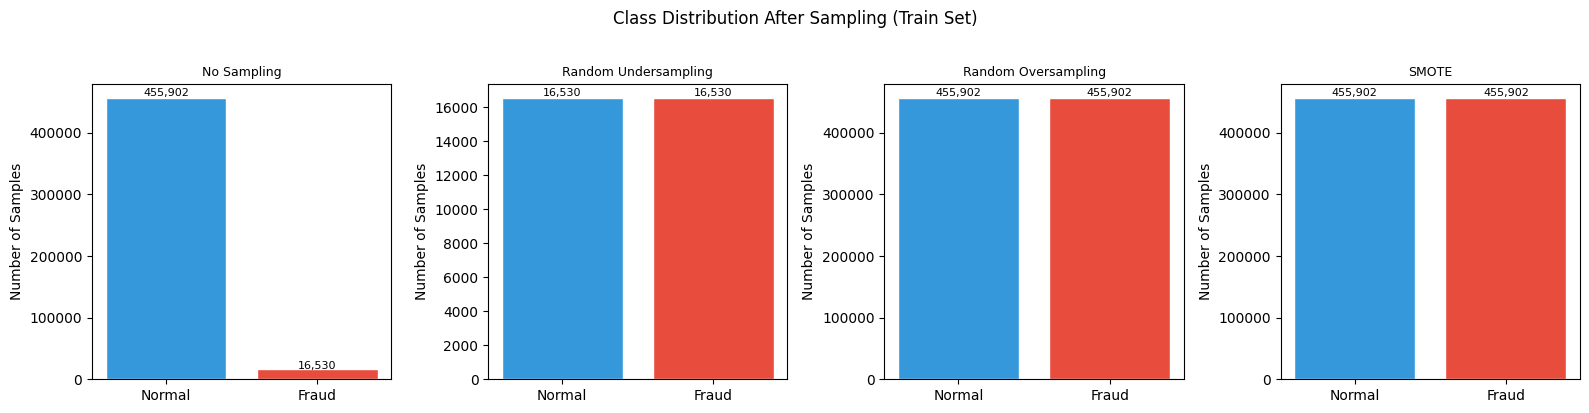

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, sampler) in zip(axes, SAMPLERS.items()):
    if sampler is None:
        y_s = y_train
    else:
        # Resample to observe the change in distribution
        _, y_s = sampler.fit_resample(X_train_s, y_train)

    counts = pd.Series(y_s).value_counts()
    ax.bar(['Normal', 'Fraud'], [counts.get(0,0), counts.get(1,0)],
           color=['#3498db', '#e74c3c'], edgecolor='white')
    
    # Setting English labels and titles
    ax.set_title(name, fontsize=9)
    ax.set_ylabel('Number of Samples')
    
    # Adding data labels on top of bars
    for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
        ax.text(i, v * 1.01, f'{v:,}', ha='center', fontsize=8)

plt.suptitle('Class Distribution After Sampling (Train Set)', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
def run_experiment(model, sampler, X_train, X_test, y_train, y_test):
    """
    Runs a specific model + sampling combination.
    Includes Confusion Matrix details (TN, FP, FN, TP).
    """
    start_time = time.time()

    # Sampling — applied only to training data
    if sampler is not None:
        X_tr, y_tr = sampler.fit_resample(X_train, y_train)
    else:
        X_tr, y_tr = X_train.copy(), y_train.copy()

    model.fit(X_tr, y_tr)

    # Prediction — using the original test set
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    duration = time.time() - start_time
    
    # Calculate Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel() # Matrisi düzleştirip değerleri çıkarıyoruz

    return {
        'Precision': round(precision_score(y_test, y_pred, zero_division=0) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
        'F1':        round(f1_score(y_test, y_pred) * 100, 2),
        'AUC':       round(roc_auc_score(y_test, y_proba) * 100, 2) if y_proba is not None else None,
        'Time_s':    round(duration, 1),
        'TN':        tn,
        'FP':        fp,
        'FN':        fn,
        'TP':        tp,
        'model_obj': model   
    }

print('Experiment function is ready.')

Experiment function is ready.


In [12]:
ALL_RESULTS = []

# Hypothetical bank costs (USD)
COST_FN = 150  # Cost of a missed fraud (False Negative)
COST_FP = 10   # Cost of a false alarm (False Positive)

def add_result(model_name, sampling_name, result_dict):
    """
    Appends the experiment result to the global list and prints metrics + Confusion Matrix + Business Cost.
    """
    # Instant cost calculation
    total_cost = (result_dict['FN'] * COST_FN) + (result_dict['FP'] * COST_FP)
    
    record = {
        'Model':    model_name,
        'Sampling': sampling_name,
        'Precision': result_dict['Precision'],
        'Recall':    result_dict['Recall'],
        'F1':        result_dict['F1'],
        'AUC':       result_dict['AUC'],
        'Time_s':    result_dict['Time_s'],
        'TN':        result_dict['TN'],
        'FP':        result_dict['FP'],
        'FN':        result_dict['FN'],
        'TP':        result_dict['TP'],
        'Total_Cost_$': total_cost  # Adding cost directly to the table
    }
    ALL_RESULTS.append(record)
    
    # Formatted print for real-time tracking (Metrics)
    print(f'  {sampling_name:<25}: P={record["Precision"]:>6.2f}  '
          f'R={record["Recall"]:>6.2f}  F1={record["F1"]:>6.2f}  '
          f'AUC={record["AUC"]:>6.2f}  ({record["Time_s"]}s)')
          
    # Formatted print for Confusion Matrix & Business Cost
    print(f'  {"":<25}  ↳ [CM] TN: {record["TN"]} | FP: {record["FP"]} | FN: {record["FN"]} | TP: {record["TP"]}')
    print(f'  {"":<25}  Estimated Cost: ${total_cost:,}\n')

print('Logging function is ready.')

Logging function is ready.


In [ ]:
# Decision Tree
print('='*90)
print('DECISION TREE')
print('='*90)

dt_params_mapping = {
    'No Sampling': dict(
        criterion='entropy',          
        max_depth=20,                 
        min_samples_split=200,        
        min_samples_leaf=100,        
        class_weight={0: 1, 1: 7},   
        random_state=42
    ),
    
    'Random Undersampling': dict(
        criterion='gini',             
        max_depth=10,                 
        min_samples_split=100,        
        min_samples_leaf=50,          
        class_weight=None,            
        random_state=42
    ),
    
    'Random Oversampling': dict(
        criterion='entropy',
        max_depth=20,               
        min_samples_split=100,        
        min_samples_leaf=50,        
        class_weight=None,            
        random_state=42
    ),
    
    'SMOTE': dict(
        criterion='entropy',         
        max_depth=15,                 
        min_samples_split=300,        
        min_samples_leaf=100,         
        class_weight=None,            
        random_state=42
    )
}

for sampling_name, sampler in SAMPLERS.items():
    
    current_params = dt_params_mapping.get(sampling_name, {})
    model = DecisionTreeClassifier(**current_params)
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                            X_train_s, X_test_s, y_train, y_test)
    
    add_result('Decision Tree', sampling_name, result)

In [ ]:
# Random Forest 
print('='*90)
print('RANDOM FOREST')
print('='*90)

rf_params_mapping = {
    'No Sampling': dict(
        n_estimators=300,             
        max_depth=40,                 
        max_features='sqrt',
        min_samples_leaf=3,           
        class_weight='balanced_subsample', 
        n_jobs=-1, 
        random_state=42
    ),
    
    'Random Undersampling': dict(
        n_estimators=200,            
        max_depth=20,                
        max_features='sqrt',
        min_samples_leaf=10,          
        class_weight=None,          
        n_jobs=-1, 
        random_state=42
    ),
    
    'Random Oversampling': dict(
        n_estimators=300,            
        max_depth=40,               
        max_features='sqrt',
        min_samples_leaf=2,          
        class_weight=None,          
        n_jobs=-1, 
        random_state=42
    ),
    
    'SMOTE': dict(
        n_estimators=300,         
        max_depth=40,                 
        max_features='sqrt',
        min_samples_leaf=4,           
        class_weight=None,          
        n_jobs=-1, 
        random_state=42
    )
}

for sampling_name, sampler in SAMPLERS.items():
    current_params = rf_params_mapping.get(sampling_name, {})
    model = RandomForestClassifier(**current_params)
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                            X_train_s, X_test_s, y_train, y_test)
    add_result('Random Forest', sampling_name, result)

In [ ]:
# AdaBoost 
print('='*90)
print('ADABOOST')
print('='*90)

ada_params_mapping = {
    'No Sampling': dict(
        estimator=DecisionTreeClassifier(max_depth=4, class_weight={0: 1, 1: 12}), 
        n_estimators=200,         
        learning_rate=0.1,  
        random_state=42
    ),
    
    'Random Undersampling': dict(
        estimator=DecisionTreeClassifier(max_depth=3, min_samples_leaf=10),
        n_estimators=200,         
        learning_rate=0.05,      
        random_state=42
    ),
    
    'Random Oversampling': dict(
        estimator=DecisionTreeClassifier(max_depth=4, min_samples_leaf=20),
        n_estimators=200,
        learning_rate=0.1,      
        random_state=42
    ),
    
    'SMOTE': dict(
        estimator=DecisionTreeClassifier(max_depth=4, min_samples_leaf=20),
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    )
}

for sampling_name, sampler in SAMPLERS.items():
    current_params = ada_params_mapping.get(sampling_name, {})
    if sampling_name in ['SMOTE', 'Random Oversampling']:
         continue
    model = AdaBoostClassifier(**current_params)
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                            X_train_s, X_test_s, y_train, y_test)
    add_result('AdaBoost', sampling_name, result)

In [ ]:
# Voting Classifier 
print('='*90)
print('VOTING CLASSIFIER')
print('='*90)

from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
import copy

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f"Log: Voting Classifier için scale_pos_weight (spw) hesaplandı: {spw:.2f}")

def create_voting(sampling_name, spw):
    if sampling_name != 'No Sampling':
        rf_weight = None
        xgb_weight = 1
    else:
        rf_weight = 'balanced_subsample'
        xgb_weight = spw / 2  

    return VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(
                    n_estimators=250,      
                    max_depth=30,         
                    min_samples_leaf=4,    
                    class_weight=rf_weight, 
                    n_jobs=-1,    
                    random_state=42)),
            
            ('xgb', XGBClassifier(
                    n_estimators=250,    
                    max_depth=7,         
                    learning_rate=0.05,
                    scale_pos_weight=xgb_weight,
                    eval_metric='logloss', 
                    n_jobs=-1,    
                    random_state=42))
        ],
        voting='soft',
        weights=[1, 1.2], 
        n_jobs=1  
    )

# Run the loop for all sampling methods
for sampling_name, sampler in SAMPLERS.items():
    
    # ------------------ RAM PROTECTION SHIELD ------------------
    if sampling_name in ['SMOTE', 'Random Oversampling']:
        print(f"Skipping [{sampling_name}]")
        continue
    # -----------------------------------------------------------

    print(f" Starting Voting Classifier for [{sampling_name}]...")
    
    model = create_voting(sampling_name, spw)
    
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                            X_train_s, X_test_s, y_train, y_test)
    
    add_result('Voting Classifier', sampling_name, result)

In [ ]:
from xgboost import XGBClassifier
import copy

# XGBoost 
print('='*90)
print('XGBOOST — Main Model')
print('='*90)

# Calculate scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count

xgb_params_mapping = {
    'No Sampling': dict(
        n_estimators=400,             
        max_depth=10,                
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw / 3,     
        eval_metric='logloss',     
        n_jobs=-1,
        random_state=42
    ),
    
    'Random Undersampling': dict(
        n_estimators=200,          
        max_depth=6,                 
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=1,        
        eval_metric='logloss',
        n_jobs=-1,
        random_state=42
    ),
    
    'Random Oversampling': dict(
        n_estimators=400,             
        max_depth=12,                 
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=1,     
        eval_metric='logloss',
        n_jobs=-1,
        random_state=42
    ),
    
    'SMOTE': dict(
        n_estimators=400,
        max_depth=12,                 
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=2,          
        eval_metric='logloss',
        n_jobs=-1,
        random_state=42
    )
}

for sampling_name, sampler in SAMPLERS.items():
    current_params = xgb_params_mapping.get(sampling_name, {})
    model = XGBClassifier(**current_params)
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                            X_train_s, X_test_s, y_train, y_test)
    
    add_result('XGBoost', sampling_name, result)

In [ ]:
# LightGBM 
print('='*90)
print('LightGBM')
print('='*90)


lgb_params_mapping = {
    'No Sampling': dict(
        n_estimators=400,           
        num_leaves=63,                
        max_depth=12,               
        learning_rate=0.05,
        scale_pos_weight=spw / 3,     
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=42
    ),
    
    'Random Undersampling': dict(
        n_estimators=200,         
        num_leaves=31,               
        max_depth=6,
        learning_rate=0.05,
        class_weight=None,        
        n_jobs=-1,
        random_state=42
    ),
    
    'Random Oversampling': dict(
        n_estimators=400,
        num_leaves=127,              
        max_depth=15,
        min_child_samples=50,        
        learning_rate=0.05,
        class_weight=None,        
        n_jobs=-1,
        random_state=42
    ),
    
    'SMOTE': dict(
        n_estimators=400,
        num_leaves=127,             
        max_depth=15,
        learning_rate=0.05,
        scale_pos_weight=2,        
        n_jobs=-1,
        random_state=42
    )
}

for sampling_name, sampler in SAMPLERS.items():
    print(f"Starting LightGBM for [{sampling_name}]...")
    current_params = lgb_params_mapping.get(sampling_name, {})   
    model = lgb.LGBMClassifier(**current_params)  
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                            X_train_s, X_test_s, y_train, y_test)
    
    add_result('LightGBM', sampling_name, result)

In [ ]:
# CatBoost 
print('='*90)
print('CatBoost')
print('='*90)

cat_params_mapping = {
    'No Sampling': dict(
        iterations=500,               
        depth=8,                      
        learning_rate=0.05,
        auto_class_weights='SqrtBalanced', 
        l2_leaf_reg=3,                
        verbose=0,                     
        random_state=42
    ),
    
    'Random Undersampling': dict(
        iterations=300,               
        depth=6,                      
        learning_rate=0.05,
        auto_class_weights=None,       
        l2_leaf_reg=5,                
        verbose=0,
        random_state=42
    ),
    
    'Random Oversampling': dict(
        iterations=500,                
        depth=10,                     
        learning_rate=0.05,
        auto_class_weights=None,       
        l2_leaf_reg=5,                 
        verbose=0,
        random_state=42
    ),
    
    'SMOTE': dict(
        iterations=500,
        depth=10,                     
        learning_rate=0.05,
        auto_class_weights=None, 
        scale_pos_weight=2,            
        l2_leaf_reg=3,
        verbose=0,
        random_state=42
    )
}

for sampling_name, sampler in SAMPLERS.items():
    print(f"Starting CatBoost for [{sampling_name}]...")
    current_params = cat_params_mapping.get(sampling_name, {})
    model = CatBoostClassifier(**current_params)    
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                            X_train_s, X_test_s, y_train, y_test)
    
    add_result('CatBoost', sampling_name, result)

In [ ]:
# Isolation Forest
print('='*90)
print('Isolation Forest')
print('='*90)


from sklearn.ensemble import IsolationForest
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class iForestWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, contamination=0.035, n_estimators=300, max_samples=256, max_features=1.0, random_state=42):
        self.contamination = contamination
        self.n_estimators = n_estimators    
        self.max_samples = max_samples      
        self.max_features = max_features    
        self.random_state = random_state
        
        self.model = IsolationForest(
            n_estimators=self.n_estimators,
            max_samples=self.max_samples,
            contamination=self.contamination,
            max_features=self.max_features,
            n_jobs=-1, 
            random_state=self.random_state
        )

    def fit(self, X, y=None):
        self.model.fit(X)
        return self

    def predict(self, X):
        preds = self.model.predict(X)
        return np.where(preds == 1, 0, 1)

    def predict_proba(self, X):
        scores = -self.model.decision_function(X) 
        scores_scaled = (scores - scores.min()) / (scores.max() - scores.min())
        return np.vstack((1 - scores_scaled, scores_scaled)).T

print(f"Starting Isolation Forest for [No Sampling] (Anomaly Detection)...")

esnek_fraud_orani = 0.07 

iforest_model = iForestWrapper(
    contamination=esnek_fraud_orani, 
    n_estimators=400,          
    max_samples=1024,         
    max_features=0.8          
)

result_if = run_experiment(iforest_model, None, X_train_s, X_test_s, y_train, y_test)
add_result('Isolation Forest', 'No Sampling', result_if)

In [ ]:
# KNN 
print('='*90)
print('KNN')
print('='*90)

knn_params_mapping = {
    'No Sampling': dict(
        n_neighbors=15,           
        weights='distance',       
        metric='manhattan',      
        n_jobs=-1
    ),
    
    'Random Undersampling': dict(
        n_neighbors=7,           
        weights='uniform',        
        metric='manhattan',
        n_jobs=-1
    ),
    
    'Random Oversampling': dict(
        n_neighbors=15,           
        weights='distance',
        metric='manhattan',
        n_jobs=-1
    ),
    
    'SMOTE': dict(
        n_neighbors=15,           
        weights='uniform',        
        metric='manhattan',
        n_jobs=-1
    )
}

# Big data warning:
# With 590K rows, KNN could take hours.
# Run by downsampling:
n_knn = min(50000, len(X_train_s))  # Train with a maximum of 50K
idx_knn = np.random.choice(len(X_train_s), n_knn, replace=False)
X_knn = X_train_s.iloc[idx_knn]
y_knn = y_train.iloc[idx_knn]
print(f'Downsampling for KNN: Using {n_knn:,} samples')

for sampling_name, sampler in SAMPLERS.items():
    print(f"Starting KNN for [{sampling_name}]...")

    current_params = knn_params_mapping.get(sampling_name, {})

    if sampling_name in ['No Sampling','SMOTE', 'Random Oversampling']:
        continue

    model = KNeighborsClassifier(**current_params)
    
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                            X_knn, X_test_s, y_knn, y_test)
    
    add_result('KNN', sampling_name, result)

print(f'\nNote: KNN was run with {n_knn:,} samples — full data may yield different results.')

In [ ]:
# SVM 
print('='*90)
print('SVM')
print('='*90)

svm_params_mapping = {
    'No Sampling': dict(
        C=1.0, 
        kernel='rbf', 
        gamma='scale', 
        class_weight={0: 1, 1: 15}, 
        probability=True, 
        random_state=42
    ),
    
    'Random Undersampling': dict(
        C=1.0, 
        kernel='rbf', 
        gamma='scale', 
        class_weight=None, 
        probability=True, 
        random_state=42
    ),
    
    'Random Oversampling': dict(
        C=1.0, 
        kernel='rbf', 
        gamma='scale', 
        class_weight=None, 
        probability=True, 
        random_state=42
    ),
    
    'SMOTE': dict(
        C=1.0, 
        kernel='rbf', 
        gamma='scale', 
        class_weight=None,
        probability=True, 
        random_state=42
    )
}

# Smaller downsampling for SVM
n_svm = min(20000, len(X_train_s))
idx_svm = np.random.choice(len(X_train_s), n_svm, replace=False)
X_svm = X_train_s.iloc[idx_svm]
y_svm = y_train.iloc[idx_svm]
print(f'Downsampling for SVM: {n_svm:,} samples')

for sampling_name, sampler in SAMPLERS.items():
    print(f"Starting SVM for [{sampling_name}]...")
    
    current_params = svm_params_mapping.get(sampling_name, {})

    if sampling_name in ['No Sampling','Random Oversampling']:
        continue

    model = SVC(**current_params)
    
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                            X_svm, X_test_s, y_svm, y_test)
    
    add_result('SVM', sampling_name, result)

In [ ]:
df_results = pd.DataFrame(ALL_RESULTS)

for sampling in ['No Sampling', 'Random Oversampling', 'Random Undersampling', 'SMOTE']:
    subset = df_results[df_results['Sampling'] == sampling]
    if len(subset) == 0:
        continue
    print(f'\n{"="*90}')
    print(f'  SAMPLING STRATEGY: {sampling.upper()}')
    print(f'{"="*90}')
    table = subset[['Model', 'Precision', 'Recall', 'F1', 'AUC', 'TP', 'FP', 'FN', 'TN', 'Time_s']]\
                .set_index('Model').sort_values('AUC', ascending=False)
    print(table.to_string())